In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import h5py
import matplotlib.pyplot as plt
import autoencoder
import config
import torch
from ipywidgets import interact
import ipywidgets as widgets



all_thbn = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='thumbnails')
train_data =autoencoder.process_thumbnails(all_thbn)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:

data_tensor = torch.tensor(train_data, dtype=torch.float32)
device = autoencoder.get_device()

model = autoencoder.ParticleAE(latent_dim=32).to(device)
model.load_state_dict(torch.load(f"{config.DATA_DIR}/model.pth", map_location=device, weights_only=True))
# 3. Get the Latent Vectors
model.eval()
with torch.no_grad():
    _, latent = model(data_tensor.to(device))
    latent = latent.cpu().numpy()

Found mps


In [4]:
# 4. Project to 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(latent)

with h5py.File(f'{config.DATA_DIR}/pca.h5', 'w') as f:
    f['/coords'] = coords
    

In [26]:
# 5. Plot!'
def plot_thumb(i):
    fig, ax = plt.subplots(1,1, figsize=(2,2))
    ax.imshow(all_thbn[i])
    #ax[1].imshow(train_data[i,0])
    plt.show()

interact(plot_thumb, i=(0, all_thbn.shape[0]-1,1))

interactive(children=(IntSlider(value=9548, description='i', max=19096), Output()), _dom_classes=('widget-inte…

<function __main__.plot_thumb(i)>

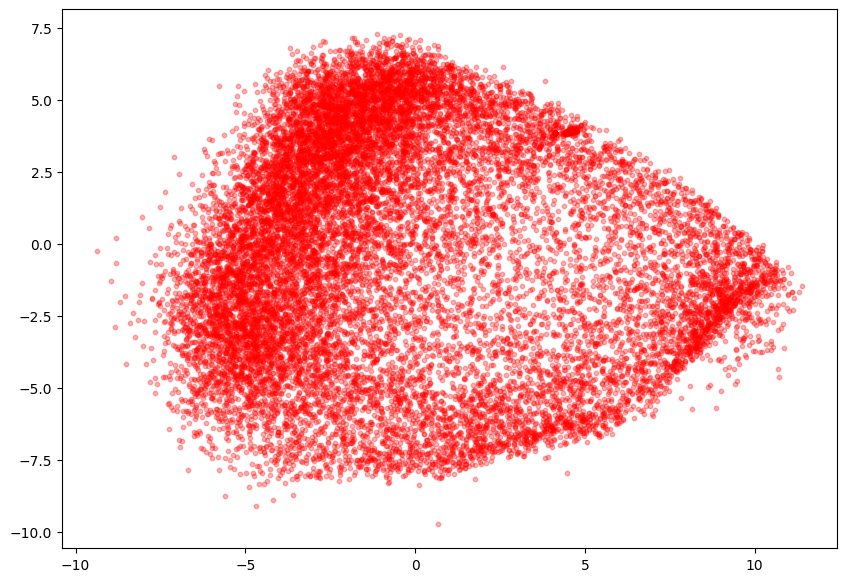

In [27]:
plt.figure(figsize=(10, 7))
# Plot rejected (Red) peaks
plt.scatter(coords[:, 0], coords[:, 1], 
        c='red', label='', alpha=0.3, s=10)

plt.show()